In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [81]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
device = torch.device('cpu')
dtype = torch.float32
L = 1
dim = 2
nx = 16
dx = L/nx

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.zeros_like(domain.min)
domain.max = torch.ones_like(domain.max) * L

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.0, 0, shiftScheme = 'delta') 
particlesLR = sampleOptimal(nx//2, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

particles = particles._replace(positions = particles.positions - dx/2)
particlesLR = particlesLR._replace(positions = particlesLR.positions - dx/4)    

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

particleState = wcstateToState(particles)


0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [82]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import numpy as np
import jax
import exponax as ex
import matplotlib.pyplot as plt
import h5py

NUM_POINTS = nx

datafile = h5py.File(f"data_diffusedNoise_nx_{nx}.h5", "r")

u0 = np.array(datafile['u_0'])
jacobian = np.array(datafile['d'])
hessian = np.array(datafile['d2'])
patrician = np.array(datafile['d3'])

selected_seed = 0

values = [u0[selected_seed], jacobian[selected_seed], hessian[selected_seed], patrician[selected_seed]]
values = [torch.tensor(v, device=device, dtype=dtype).flatten(-2).T for v in values]

for v in values:
    print(v.shape)

torch.Size([256, 1])
torch.Size([256, 2])
torch.Size([256, 2, 2])
torch.Size([256, 2, 2, 2])


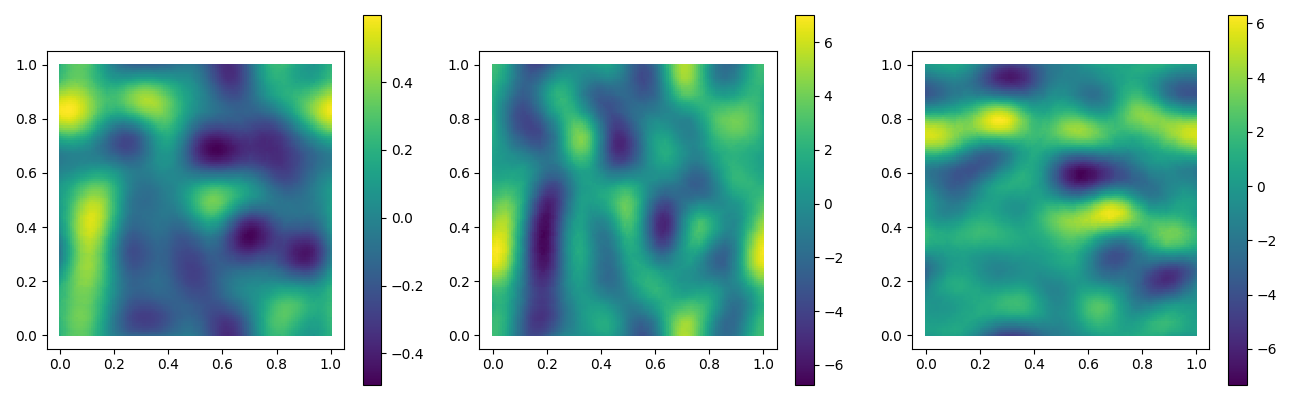

In [83]:
fig, axis = plt.subplots(1, 3, figsize=(13, 4), squeeze = False)

plot = visualizeParticles(fig, axis[0, 0],
  particles = particleState,
  domain = domain,
  quantity = values[0],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axis[0, 1],
  particles = particleState,
  domain = domain,
  quantity = values[1],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,  
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)


plot = visualizeParticles(fig, axis[0, 2],
  particles = particleState,
  domain = domain,
  quantity = values[1],
  which = 'fluid',
  mapping = '.y',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)


fig.tight_layout()


In [84]:
from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, coo_to_csr, SparseNeighborhood
def buildSparseNeighborhood(neighborhood):
    i = neighborhood.row
    j = neighborhood.col

    return SparseNeighborhood(
        row = i,
        col = j,
        numRows = neighborhood.numRows,
        numCols = neighborhood.numCols,

        points_a = neighborhood.points_a,
        points_b = neighborhood.points_b,

        domain = neighborhood.domain,
    )

Number of neighbors: torch.Size([256]) tensor([45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
 

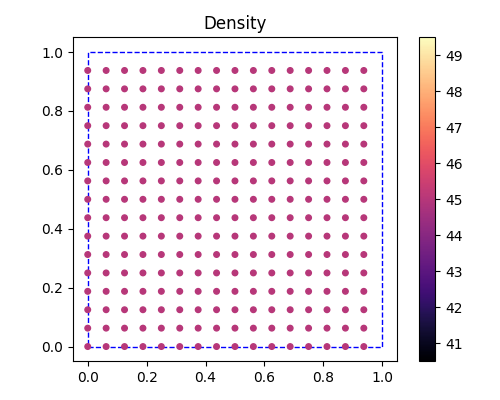

In [85]:

mode = SupportScheme.SuperSymmetric
mode_str = mode.name
mode_str = mode_str[0].lower() + mode_str[1:]

neighborhood, sparseNeighborhood_ = buildNeighborhood(particleState, particleState, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)


numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries

print('Number of neighbors:', numNeighbors.shape, numNeighbors)

fig, axis = plt.subplots(1,1 , figsize=(5,4), squeeze=False)
markerSize = 16
visualizeParticles(fig, axis[0,0], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Density')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [86]:
inputFeatures = values[0]

gt = values[0]**2

print(f'Input features: {inputFeatures.shape}, GT: {gt.shape}')
print(f'Input features statistics: max: {inputFeatures.max()}, min: {inputFeatures.min()}, mean: {inputFeatures.mean()}, std: {inputFeatures.std()}')
print(f'GT statistics: max: {gt.max()}, min: {gt.min()}, mean: {gt.mean()}, std: {gt.std()}')

Input features: torch.Size([256, 1]), GT: torch.Size([256, 1])
Input features statistics: max: 0.9999999403953552, min: -0.9529105424880981, mean: 1.862645149230957e-09, std: 0.3851446509361267
GT statistics: max: 0.9999998807907104, min: 4.389895877920935e-07, mean: 0.14775696396827698, std: 0.1911180466413498


In [87]:
latentSpaceSize = 17
hiddenMLPSize = 61
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

transformerFeatures = 5
multiHeads = 4
batch_size = 1
num_nodes = inputFeatures.shape[0]
latentSpaceSize = 17
dim = particleState.positions.shape[-1]

In [88]:
from diffSPH.neighborhood import computeSparseDistanceTensor, filterNeighborhood, SparseNeighborhood, NeighborhoodInformation

# @torch.jit.script
def filterNeighborhood(neighborhood: SparseNeighborhood, mode: str = 'superSymmetric'):
    if isinstance(neighborhood, NeighborhoodInformation):
        raise ValueError('Cannot filter neighborhood with NeighborhoodInformation')

    # adjacency = neighborhood.fullAdjacency
    row, col = neighborhood.row, neighborhood.col
    rij, xij = computeSparseDistanceTensor(neighborhood, normalize = True, mode = mode)
    mask = rij <= 1
    # print(mask)
    # print(rij, 'max: ', rij.max().item())
    # print(torch.sum(mask).item(), 'out of', rij.shape[0], 'edges kept')
    return SparseNeighborhood(row[mask], col[mask], numRows = neighborhood.numRows, numCols = neighborhood.numCols,
                                points_a = neighborhood.points_a, points_b = neighborhood.points_b,
                                domain = neighborhood.domain)


print(neighbors.neighbors.row.shape)
filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
h_i = particleState.supports[filteredNeighborhood.row].to(device)
rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
sparse_edge_attr = xij_ / h_i[:,None]

print('Maximum distance: ', (rij / h_i).max().item())

torch.Size([11520])
Maximum distance:  0.9013878107070923


In [89]:
from models.common import CommonConfiguration
import copy

baseConfigNoEncoders = CommonConfiguration(
    token_input_dim=transformerFeatures * multiHeads,
    token_output_dim=transformerFeatures * multiHeads,
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=1,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    mlp_hidden_layers=2,
    mlp_latent_dim = 32,
    mlp_activation = 'silu',
)

baseConfig = copy.deepcopy(baseConfigNoEncoders)

In [90]:
from layers.layer_tokenEncoder import TokenEncoderConfig
encodeConfig = TokenEncoderConfig()

display(encodeConfig)
encodeConfig.projection_linear=False

TokenEncoderConfig(token_input_dim=0, token_output_dim=None, token_latent_dim=None, skip_connection=True, projection=True, projection_linear=True, projection_mlp_dict=None, position_bias=None, position_bias_mixing=None, position_bias_linear=True, position_bias_mlp_dict=None, position_bias_dim=None, use_ffn=False, ffn_linear=False, ffn_mlp_dict=None, ffn_skip_connection=False, pre_norm=False, post_norm=False, final_activation=None)

In [104]:
from models.basicTransformer import BasicTransformer
from models.ContinuousConvolution import CConvModel, BasicCConvLayer
from models.GNN import GNNModel
import torch.nn as nn
from models.basicEncoder import BasicEncoder

class basicTest(nn.Module):
    def __init__(self, 
                 input_dim, output_dim,
                 transformer_features, multi_heads,
                 latent_dim, latent_layers,
                 encoderConfig, decoderConfig, transformerConfig, 
                 numTransformers, mode = 'transformer'):
        super(basicTest, self).__init__()
        self.inputEncoder = BasicEncoder(
            input_dim = input_dim,
            output_dim = transformer_features * multi_heads,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            tokenEncoderConfig=encoderConfig,
            verbose = False,
        )
        self.transformers = nn.ModuleList()
        for _ in range(numTransformers):
            if mode == 'transformer':
                transformer = BasicTransformer(
                    config = transformerConfig,
                    transformer_features = transformer_features,
                    attention_heads = multi_heads,

                    # attention_softmax = False,

                    verbose = False,
                )
            elif mode == 'cconv':
                transformer = CConvModel(
                    config=baseConfigNoEncoders,

                    verbose = False,
                )
            elif mode == 'gnn':
                transformer = GNNModel(
                    config = baseConfigNoEncoders,

                    use_edge_mlp=True,
                    use_edge_encoder = True,
                    inputEdgeEncoderTokenConfig = None,
                    verbose = False,
                )
            self.transformers.append(transformer)
        self.decoder = BasicEncoder(
            input_dim = transformer_features * multi_heads,
            output_dim = output_dim,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            tokenEncoderConfig=decoderConfig,
            verbose = False,
        )

    def forward(self, node_attr, edge_attr, edge_index, node_positions):
        print('Input node_attr shape:', node_attr.shape)
        x = self.inputEncoder(node_attr, inputPositions = node_positions)
        print('Encoded input shape:', x.shape)
        for transformer in self.transformers:
            x = transformer(
                node_features = x,
                node_positions = node_positions[0],
                edge_indices = edge_index,
                edge_features = None,
                edge_spatial_features = edge_attr)
            # print('Transformed shape:', x.shape)
        out = self.decoder(x, inputPositions = node_positions)
        print('Output shape:', out.shape)
        return out
    
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

multiHeads = 1
transformerFeatures = 33



baseConfigNoEncoders = CommonConfiguration(
    token_input_dim=transformerFeatures * multiHeads,
    token_output_dim=transformerFeatures * multiHeads,
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=4,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    mlp_hidden_layers=3,
    mlp_latent_dim = 32,
    mlp_activation = 'tanh',
)

basicModel = basicTest(
    input_dim = inputFeatures.shape[-1],
    output_dim = gt.shape[-1],
    transformer_features = transformerFeatures,
    multi_heads = multiHeads,
    latent_dim = 32,
    latent_layers = 1,
    encoderConfig = encodeConfig,
    decoderConfig = encodeConfig,
    transformerConfig = baseConfigNoEncoders,
    numTransformers = 0,
    mode = 'gnn'
).to(device)

In [105]:
inputFeatures = values[0]

inputFeatures = torch.sin(particleState.positions[:,0].view(-1,1)*2*np.pi)
# 
gt = values[0]**2
gt = inputFeatures**2
# gt = values[1][:,0].view(-1,1)
# gt = torch.cos(particleState.positions[:,0].view(-1,1)*2*np.pi) * 2

# gt = 2 * particleState.positions[:,0].view(-1,1)

print(f'Input features: {inputFeatures.shape}, GT: {gt.shape}')
print(f'Input features statistics: max: {inputFeatures.max()}, min: {inputFeatures.min()}, mean: {inputFeatures.mean()}, std: {inputFeatures.std()}')
print(f'GT statistics: max: {gt.max()}, min: {gt.min()}, mean: {gt.mean()}, std: {gt.std()}')

neighborhood, sparseNeighborhood_ = buildNeighborhood(particleState, particleState, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)

filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
h_i = particleState.supports[filteredNeighborhood.row].to(device)
rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
edge_attr = xij_ / h_i[:,None]

node_attr = (inputFeatures.unsqueeze(0), inputFeatures.unsqueeze(0))
edge_indices = torch.stack([filteredNeighborhood.row, filteredNeighborhood.col], dim=0)
node_positions = (particleState.positions, particleState.positions)


print(edge_indices.shape)

basicPred = basicModel(node_attr[0], edge_attr, edge_indices, node_positions[0]).squeeze(0)


Input features: torch.Size([256, 1]), GT: torch.Size([256, 1])
Input features statistics: max: 1.0, min: -1.0, mean: 5.587935447692871e-09, std: 0.7084919214248657
GT statistics: max: 1.0, min: 0.0, mean: 0.5, std: 0.35424596071243286
torch.Size([2, 11520])
Input node_attr shape: torch.Size([1, 256, 1])
Encoded input shape: torch.Size([1, 256, 33])
Output shape: torch.Size([1, 256, 1])


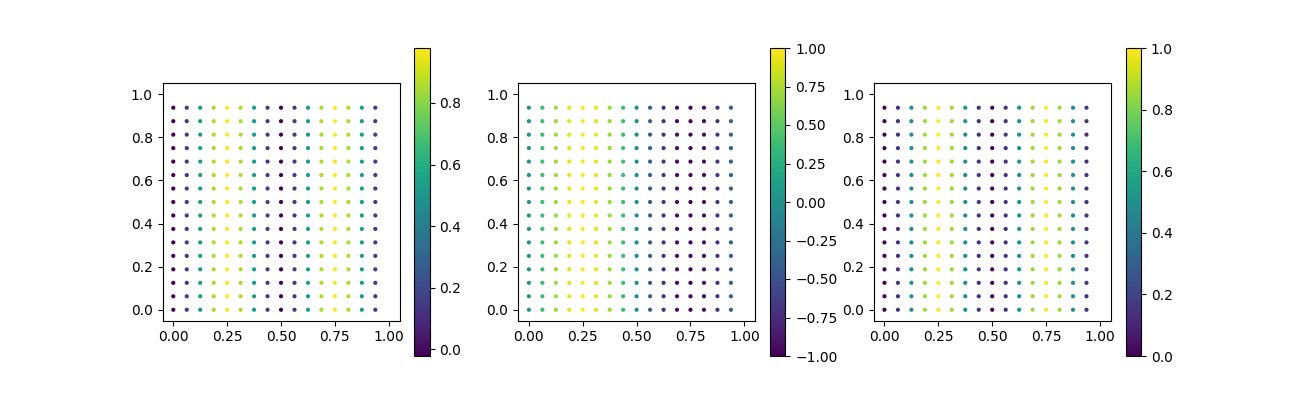

In [109]:
fig, axis = plt.subplots(1, 3, figsize=(13, 4), squeeze = False)

plot = visualizeParticles(fig, axis[0, 0],
  particles = particleState,
  domain = domain,
  quantity = basicPred.detach(),
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axis[0, 2],
  particles = particleState,
  domain = domain,
  quantity = gt,
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
    visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axis[0, 1],
  particles = particleState,
  domain = domain,
  quantity = inputFeatures,
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)


In [107]:
optimizer = torch.optim.Adam(basicModel.parameters(), lr=1e-2)
numberOfParameters = count_parameters(basicModel)
print(f'Number of parameters in the model: {numberOfParameters}')

basicPred = basicModel(node_attr[0], edge_attr, edge_indices, node_positions[0]).squeeze(0)

print(basicPred)

Number of parameters in the model: 12800
Input node_attr shape: torch.Size([1, 256, 1])
Encoded input shape: torch.Size([1, 256, 33])
Output shape: torch.Size([1, 256, 1])
tensor([[ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 1.6791e-02],
        [ 2.9129e-02],
        [ 2.9129e-02],
        [ 2.9129e-02],
        [ 2.9129e-02],


In [108]:
losses_transformer2 = []
for i in (tq := tqdm(range(2**14), desc='Training', unit='epoch')) :
    optimizer.zero_grad()
    basicPred = basicModel(node_attr[0], edge_attr, edge_indices, node_positions[0]).squeeze(0) * 100

    # print(basicPred.shape, gt.shape)
    # print(basicPred)
    fluidPred = basicPred#[particleState.kinds == 0]
    fluidGT = gt#[particleState.kinds == 0]

    fluidLoss = torch.nn.functional.mse_loss(fluidPred, fluidGT)

    fluidLoss = ((fluidPred - fluidGT)**2).mean()
    # print('Fluid loss:', fluidLoss.item())

    # loss = torch.nn.functional.mse_loss(basicPred, gt)
    fluidLoss.backward()
    optimizer.step()
    tq.set_postfix({'loss': fluidLoss.item()})
    losses_transformer2.append(fluidLoss.item())

    # break

Training:   0%|          | 0/16384 [00:00<?, ?epoch/s]

Input node_attr shape: torch.Size([1, 256, 1])
Encoded input shape: torch.Size([1, 256, 33])
Output shape: torch.Size([1, 256, 1])
Input node_attr shape: torch.Size([1, 256, 1])
Encoded input shape: torch.Size([1, 256, 33])
Output shape: torch.Size([1, 256, 1])
Input node_attr shape: torch.Size([1, 256, 1])
Encoded input shape: torch.Size([1, 256, 33])
Output shape: torch.Size([1, 256, 1])
Input node_attr shape: torch.Size([1, 256, 1])
Encoded input shape: torch.Size([1, 256, 33])
Output shape: torch.Size([1, 256, 1])
Input node_attr shape: torch.Size([1, 256, 1])
Encoded input shape: torch.Size([1, 256, 33])
Output shape: torch.Size([1, 256, 1])
Input node_attr shape: torch.Size([1, 256, 1])
Encoded input shape: torch.Size([1, 256, 33])
Output shape: torch.Size([1, 256, 1])
Input node_attr shape: torch.Size([1, 256, 1])
Encoded input shape: torch.Size([1, 256, 33])
Output shape: torch.Size([1, 256, 1])
Input node_attr shape: torch.Size([1, 256, 1])
Encoded input shape: torch.Size([1, 

KeyboardInterrupt: 

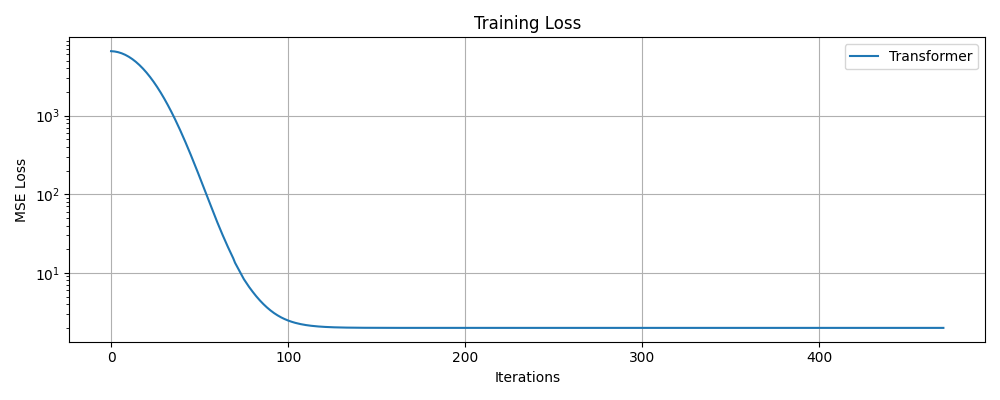

In [ ]:
fig, axis = plt.subplots(1,1 , figsize=(10,4), squeeze=False)

# axis[0,0].plot(gaussian_filter1d(losses, sigma=16), label = 'GNN')
# axis[0,0].plot(gaussian_filter1d(losses_transformer, sigma=16), label = 'Transformer')
axis[0,0].plot(gaussian_filter1d(losses_transformer2, sigma=16), label = 'Transformer')
# axis[0,0].plot(gaussian_filter1d(losses_cconv, sigma=16), label = 'CConv')

axis[0,0].set_yscale('log')
axis[0,0].set_title('Training Loss')
axis[0,0].legend()

axis[0,0].grid(True)
axis[0,0].set_xlabel('Iterations')
axis[0,0].set_ylabel('MSE Loss')

fig.tight_layout()

In [ ]:

pred = basicPred.squeeze(0)

print('pred shape:', pred.shape, 'gt shape:', gt.shape)

loss = torch.nn.functional.mse_loss(pred, gt)
print('Loss:', loss.item())

pred shape: torch.Size([17196, 2]) gt shape: torch.Size([17196, 2])
Loss: 0.06757645308971405


In [ ]:
from models.ContinuousConvolution import CConvModel, BasicCConvLayer
from models.GNN import GNNModel


cconvModel = CConvModel(
    config=baseConfig,

    verbose = False,
).to(device)

cconvModelNoEncoders = CConvModel(
    config=baseConfigNoEncoders,

    verbose = False,
).to(device)


In [ ]:
outA = cconvModel(
    node_features = node_attr_batched[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
)
outB = decoder(cconvModelNoEncoders(
    node_features = encodedNodes[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
))

In [ ]:
from models.GNN import GNNModel

gnn = GNNModel(
    config = baseConfig,

    use_edge_mlp=True,
    use_edge_encoder = True,
    inputEdgeEncoderTokenConfig = None,
    verbose = False,
).to(device)

gnnNoEncoders = GNNModel(
    config = baseConfigNoEncoders,

    use_edge_mlp=True,
    use_edge_encoder = True,
    inputEdgeEncoderTokenConfig = None,
    verbose = False,
).to(device)

In [ ]:
outA = gnn(
    node_features = node_attr_batched[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
)
outB = decoder(gnnNoEncoders(
    node_features = encodedNodes[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
))